In [106]:
%matplotlib inline
import numpy as np
import pandas as pd
import pickle
import os
import scipy.io
import scanpy as sc
import anndata as ad
import seaborn as sns
from statsmodels.stats import multitest

%config InlineBackend.figure_format = 'retina'

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=120)

The `sinfo` package has changed name and is now called `session_info` to become more discoverable and self-explanatory. The `sinfo` PyPI package will be kept around to avoid breaking old installs and you can downgrade to 0.3.2 if you want to use it without seeing this message. For the latest features and bug fixes, please install `session_info` instead. The usage and defaults also changed slightly, so please review the latest README at https://gitlab.com/joelostblom/session_info.
-----
anndata     0.7.8
scanpy      1.8.1
sinfo       0.3.4
-----
PIL                 8.1.0
backcall            0.1.0
cached_property     1.5.2
cffi                1.15.0
cloudpickle         2.0.0
constants           NA
cycler              0.10.0
cython_runtime      NA
cytoolz             0.11.2
dask                2022.02.0
dateutil            2.8.1
decorator           4.4.1
fsspec              2022.3.0
h5py                3.6.0
highs_wrapper       NA
ipykernel           5.1.3
ipython_genutils    0.2.0
jedi  

In [4]:
os.chdir('/lustre1/project/stg_00003/groups/SHLI/')

In [5]:
adata = sc.read_h5ad('adata_08082022.h5ad')

In [6]:
adata.obs

,Age,Condition,Genotype,Run,Singlet,Sleep_Stage,Treatment,doublet_scores,n_counts,n_genes,...,Neurotransmitter,all_res8,HRG_sqrt,CRG_sqrt,Cluster_ID_res8_240622,Cluster_ID_res8_070722,Cluster_ID_res8_080822,ring_3clusters,neuron_glia,neuron_glia_pos
index,,,,,,,,,,,,,,,,,,,,,
AAACCCAAGGAGGCAG-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 8 wake,line_88,20180419,True,ZT_8,Wake,0.042720,7702.0,2211,...,Unknown,nonPAM,10.440307,1.914854,nonPAM,nonPAM,nonPAM,NaN,neuron,neuron
AAACCCAAGGGTCACA-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 20 sleep,line_441,20180419,True,ZT_20,Sleep,0.027581,8043.0,2246,...,Cholinergic,201,5.385165,0.000000,201,201,201,NaN,neuron,neuron
AAACCCACAAATACAG-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 8 wake stimulation,line_313,20180419,True,ZT_8,Wake,0.053623,655.0,411,...,Unknown,ALG-,3.316625,0.000000,133,133,133,NaN,glia,133
AAACCCACAAGCACCC-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 20 sleep,line_441,20180419,True,ZT_20,Sleep,0.027581,3774.0,1492,...,Cholinergic,90,6.782330,4.281744,90,90,90,NaN,neuron,neuron
AAACCCACAAGTGGAC-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 20 sleep,line_441,20180419,True,ZT_20,Sleep,0.058220,15036.0,3112,...,Cholinergic,34,3.162278,4.358899,34,34,34,NaN,neuron,neuron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCTGTAAGC-fcae49__S3_10x_240920-20200924,7 days,ZT 8 gab,line_287,20200924,True,ZT_8,Sleep,0.036336,1589.0,797,...,Cholinergic,138,0.000000,0.000000,138,138,138,NaN,neuron,neuron
TTTGTTGAGGAACTCG-fcae49__S3_10x_240920-20200924,6-8 days,ZT 8 gab,line_441,20200924,True,ZT_8,Sleep,0.010993,1490.0,809,...,Glutamatergic,67,0.000000,5.972158,67,67,67,NaN,neuron,neuron
TTTGTTGCAACCAATC-fcae49__S3_10x_240920-20200924,7 days,ZT 8 wake,line_379,20200924,True,ZT_8,Wake,0.012016,4453.0,1483,...,Unknown,26,6.928203,6.952218,26,26,26,NaN,neuron,neuron


In [7]:
template_keys = [
    'ZT 8 gab',
    'ZT 20 sleep',
    'ZT 14 sleep',
    'ZT 14 SD',
    'ZT 20 sleep deprivation',
    'ZT 2 sleep drive 14h SD',
    'ZT 8 20h SD'
]

In [8]:
for cond in template_keys:
    if cond not in set(adata.obs['Condition'].values):
        print(cond)

In [9]:
template_vals = np.linspace(0, 1, len(template_keys))

In [10]:
template_dict = {k: v for k, v in zip(template_keys, template_vals)}

In [11]:
template_dict

{'ZT 8 gab': 0.0,
 'ZT 20 sleep': 0.16666666666666666,
 'ZT 14 sleep': 0.3333333333333333,
 'ZT 14 SD': 0.5,
 'ZT 20 sleep deprivation': 0.6666666666666666,
 'ZT 2 sleep drive 14h SD': 0.8333333333333333,
 'ZT 8 20h SD': 1.0}

In [12]:
cluster_dict = dict.fromkeys(adata.obs['Cluster_ID_res8_080822'], "clusters")

In [13]:
cluster_dict.keys()

dict_keys(['nonPAM', '201', '133', '90', '34', '13', '80', 'y', '4', '57', 'EG_2', '9', '32', '36', '138', '28', '193', '117', '143', '46', '30', '126', '130', '26', 'ab', '97', '196', '51', '10', '123', '56', '43', '29', '77', 'adPN', '55', '38', '35', '45', '98', '115', '61', '22', '74', '49', '186', '127', '105', '58', '72', '70', '20', '69', '128', '131', '116', '81', '87', '44', '78', 'ALG', '11', '52', '41', '68', '99', 'EG_1', '8', '110', '157', '7', '23', 'abp', '104', '112', 'PG', '124', 'dFB', '158', '5-HT', '27', '16', '119', '47', 'PAM', '18', '94', '48', '182', '0', '142', '14', '86', 'CXG', '191', '148', '63', '31', '33', '163', '176', '199', '40', '177', '144', '24', '125', '113', '162', '187', '39', '96', '178', '172', '106', '62', 'ring_B', '91', '108', '50', '102', '73', 'ring_A', '54', '122', '53', '161', '66', 'PB45', '114', '67', '88', '154', '205', '59', '93', 'R5', '203', '179', '147', '107', '65', '141', '174', '42', '76', '89', '149', '83', '175', '139', '60', 

In [14]:
#create meta matrix per cell type
ct_mms = {}
for cell_type in cluster_dict.keys():
    meta_matrix = pd.DataFrame(columns = template_keys, index = adata.raw.var_names)
    try:
        for cond in meta_matrix.columns:
            subset = adata[np.logical_and(adata.obs['Condition'] == cond, adata.obs['Cluster_ID_res8_080822'] == cell_type)]
            meta_matrix[cond] = np.array(subset.raw.X.mean(axis=0))[0]
        ct_mms[cell_type] = meta_matrix
    except ZeroDivisionError: 
        print(f'Cell type fails {cell_type}')
        continue

Cell type fails 13
Cell type fails 193
Cell type fails 117
Cell type fails 125
Cell type fails 205
Cell type fails 202
Cell type fails 3
Cell type fails 195
Cell type fails 5
Cell type fails 188
Cell type fails 208
Cell type fails 6
Cell type fails 25
Cell type fails 209
Cell type fails 75
Cell type fails 103
Cell type fails 21
Cell type fails 15
Cell type fails 2


In [75]:
#clusters with no cells in one of the conditions Cluster_ID_res8.0_070722 or Cluster_ID_res8_080822
no_cells_list = ['13', '193', '117', '125', '205', '202', '3', '195', '5', '188', '208', '6', '25', '209', '75', '103', '21', '15', '2']

In [16]:
ct_mms

{'nonPAM':            ZT 8 gab  ZT 20 sleep  ZT 14 sleep  ZT 14 SD  \
 index                                                     
 l(2)gl     0.000000     0.005827     0.000000  0.000000   
 Ir21a      0.000000     0.000000     0.000000  0.000000   
 CR43609    0.147291     0.000000     0.000000  0.000000   
 Cda5       0.226866     0.197017     0.223648  0.229070   
 CR45339    0.000000     0.000000     0.000000  0.028543   
 ...             ...          ...          ...       ...   
 mt:Cyt-b   4.083395     4.403076     4.705532  4.764457   
 mt:ND1     2.445640     2.045220     2.461590  2.300959   
 mt:lrRNA   4.298258     4.317979     5.853796  5.723995   
 mt:tRNA:V  0.000000     0.032587     0.056898  0.039175   
 mt:srRNA   0.833153     0.916871     2.242055  1.876763   
 
            ZT 20 sleep deprivation  ZT 2 sleep drive 14h SD  ZT 8 20h SD  
 index                                                                     
 l(2)gl                    0.027319                 0.00

In [17]:
#calculate pearson r and adj pvalue
ct_corrs = {}
for cell_type in cluster_dict.keys():
    if cell_type in no_cells_list: continue
    meta_matrix = ct_mms[cell_type]
    corrs = pd.DataFrame(index = meta_matrix.index, columns = ['Pearson_r2', 'p-value'])
    for g, vals in meta_matrix.iterrows():
        rp = scipy.stats.pearsonr(vals, template_vals)
        corrs.loc[g] = rp
    pa = multitest.multipletests(corrs['p-value'], method='fdr_bh', alpha=0.05)
    corrs['p-adj'] = pa[1]
    print(f'{cell_type}, {sum(pa[0])}')
    ct_corrs[cell_type] = corrs

/data/leuven/334/vsc33403/jupyter/envs/jupyter/lib/python3.7/site-packages/scipy/stats/stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


nonPAM, 5181
201, 6393
133, 5044
90, 3300
34, 819
80, 5072
y, 0
4, 0
57, 0
EG_2, 2725
9, 188
32, 4191
36, 0
138, 0
28, 0
143, 0
46, 0
30, 0
126, 5234
130, 5082
26, 5046
ab, 0
97, 0
196, 5066
51, 0
10, 0
123, 23
56, 5017
43, 48
29, 257
77, 1077
adPN, 0
55, 0
38, 0
35, 0
45, 0
98, 0
115, 178
61, 344
22, 0
74, 0
49, 0
186, 6970
127, 5121
105, 1863
58, 445
72, 5086
70, 262
20, 0
69, 0
128, 442
131, 5155
116, 0
81, 1766
87, 0
44, 5063
78, 5103
ALG, 4265
11, 0
52, 0
41, 355
68, 0
99, 0
EG_1, 2574
8, 0
110, 5230
157, 5053
7, 0
23, 0
abp, 759
104, 2089
112, 0
PG, 0
124, 1025
dFB, 6800
158, 1335
5-HT, 0
27, 78
16, 1137
119, 0
47, 5056
PAM, 1324
18, 3168
94, 0
48, 5038
182, 6690
0, 236
142, 1105
14, 0
86, 3921
CXG, 2534
191, 3712
148, 0
63, 497
31, 0
33, 0
163, 0
176, 865
199, 6120
40, 2314
177, 5013
144, 1077
24, 0
113, 0
162, 3837
187, 5501
39, 0
96, 301
178, 2599
172, 0
106, 5049
62, 0
ring_B, 0
91, 5253
108, 2009
50, 2825
102, 364
73, 3385
ring_A, 26
54, 5338
122, 0
53, 5089
161, 5040
66, 0


# filter genes with adjusted p-value < 0.05

In [18]:
low_padj = {}

In [19]:
for cell_type in cluster_dict.keys():
    if cell_type in no_cells_list: continue
    corrs = ct_corrs[cell_type]
    low = corrs[corrs['p-adj'] <= 0.05]
    low_sorted = low.sort_values('Pearson_r2', ascending=True).index
    print(f'{cell_type} has {low.shape[0]} genes p-adj < 0.05')
    low_padj[cell_type] = low_sorted

nonPAM has 109 genes p-adj < 0.05
201 has 29 genes p-adj < 0.05
133 has 11 genes p-adj < 0.05
90 has 46 genes p-adj < 0.05
34 has 10 genes p-adj < 0.05
80 has 62 genes p-adj < 0.05
y has 0 genes p-adj < 0.05
4 has 0 genes p-adj < 0.05
57 has 0 genes p-adj < 0.05
EG_2 has 43 genes p-adj < 0.05
9 has 2 genes p-adj < 0.05
32 has 49 genes p-adj < 0.05
36 has 0 genes p-adj < 0.05
138 has 0 genes p-adj < 0.05
28 has 0 genes p-adj < 0.05
143 has 0 genes p-adj < 0.05
46 has 0 genes p-adj < 0.05
30 has 0 genes p-adj < 0.05
126 has 51 genes p-adj < 0.05
130 has 82 genes p-adj < 0.05
26 has 48 genes p-adj < 0.05
ab has 0 genes p-adj < 0.05
97 has 0 genes p-adj < 0.05
196 has 74 genes p-adj < 0.05
51 has 0 genes p-adj < 0.05
10 has 0 genes p-adj < 0.05
123 has 1 genes p-adj < 0.05
56 has 19 genes p-adj < 0.05
43 has 2 genes p-adj < 0.05
29 has 6 genes p-adj < 0.05
77 has 19 genes p-adj < 0.05
adPN has 0 genes p-adj < 0.05
55 has 0 genes p-adj < 0.05
38 has 0 genes p-adj < 0.05
35 has 0 genes p-adj

In [20]:
len(low_padj)

195

In [38]:
clusters_HAG = tuple(low_padj.keys())

In [42]:
clusters_HAG

('nonPAM',
 '201',
 '133',
 '90',
 '34',
 '80',
 'y',
 '4',
 '57',
 'EG_2',
 '9',
 '32',
 '36',
 '138',
 '28',
 '143',
 '46',
 '30',
 '126',
 '130',
 '26',
 'ab',
 '97',
 '196',
 '51',
 '10',
 '123',
 '56',
 '43',
 '29',
 '77',
 'adPN',
 '55',
 '38',
 '35',
 '45',
 '98',
 '115',
 '61',
 '22',
 '74',
 '49',
 '186',
 '127',
 '105',
 '58',
 '72',
 '70',
 '20',
 '69',
 '128',
 '131',
 '116',
 '81',
 '87',
 '44',
 '78',
 'ALG',
 '11',
 '52',
 '41',
 '68',
 '99',
 'EG_1',
 '8',
 '110',
 '157',
 '7',
 '23',
 'abp',
 '104',
 '112',
 'PG',
 '124',
 'dFB',
 '158',
 '5-HT',
 '27',
 '16',
 '119',
 '47',
 'PAM',
 '18',
 '94',
 '48',
 '182',
 '0',
 '142',
 '14',
 '86',
 'CXG',
 '191',
 '148',
 '63',
 '31',
 '33',
 '163',
 '176',
 '199',
 '40',
 '177',
 '144',
 '24',
 '113',
 '162',
 '187',
 '39',
 '96',
 '178',
 '172',
 '106',
 '62',
 'ring_B',
 '91',
 '108',
 '50',
 '102',
 '73',
 'ring_A',
 '54',
 '122',
 '53',
 '161',
 '66',
 'PB45',
 '114',
 '67',
 '88',
 '154',
 '59',
 '93',
 'R5',
 '203',
 '17

# filter out batch effect genes

In [69]:
batch_effect_genes = pd.read_excel('/lustre1/project/stg_00003/groups/SHLI/batch_effects.xlsx', sheet_name = "all")

In [70]:
batch_effect_genes_list = list(batch_effect_genes["gene"])
batch_effect_genes_list

['GstE4',
 'cato',
 'CG3117',
 'CR45600',
 'CG31157',
 'CG6912',
 'fw',
 'sdic3',
 'CR45175',
 'CR44841',
 'CG30428',
 'RhoGEF2',
 'Rs1',
 'CG9975',
 'CG7091',
 'Hsc70-2',
 'CG1678',
 'CG34220',
 'CG34324',
 'CG14125',
 'Muc68D',
 'Eh',
 'CR41609',
 'CG14645',
 'CG3906',
 'Peritrophin-15a',
 'CG11672',
 'Cyp4g1',
 'CG4783',
 'CG5399',
 'alrm',
 'nSyb',
 'CadN',
 'brp',
 'noe',
 'Hug',
 'Trissin',
 'Dsk',
 'CR40469',
 'mt:srRNA',
 'Ms',
 'Ilp2',
 'CG12239']

In [71]:
df = pd.DataFrame.from_dict(low_padj, orient = "index").sort_index().stack().reset_index(level=1,drop=True).reset_index()
df

,index,0
0,0,CG11208
1,0,RhoGEF3
2,1,GlcAT-I
3,1,CG30428
4,1,Rx
...,...,...
5369,nonPAM,Lsm11
5370,nonPAM,galectin
5371,nonPAM,CG17359
5372,ring_A,Ranbp16


In [72]:
df.columns = ['cluster', 'gene']

In [73]:
df_nobatch = df[~df['gene'].isin(batch_effect_genes_list)]
df_nobatch

,cluster,gene
0,0,CG11208
1,0,RhoGEF3
2,1,GlcAT-I
4,1,Rx
5,1,D12
...,...,...
5369,nonPAM,Lsm11
5370,nonPAM,galectin
5371,nonPAM,CG17359
5372,ring_A,Ranbp16


In [131]:
df_nobatch_len=pd.DataFrame.from_dict(df_nobatch['cluster'].value_counts().to_dict(), orient="index").reset_index(level=0)
df_nobatch_len

,index,0
0,85,148
1,109,139
2,190,123
3,dFB,121
4,Oct,119
...,...,...
122,42,1
123,184,1
124,129,1
125,128,1


In [132]:
df_nobatch_len.columns = ['cluster', 'n_HAG']
df_nobatch_len

,cluster,n_HAG
0,85,148
1,109,139
2,190,123
3,dFB,121
4,Oct,119
...,...,...
122,42,1
123,184,1
124,129,1
125,128,1


In [76]:
all_clusters_list = list(set(adata.obs['Cluster_ID_res8_080822'].values.tolist()))
len(all_clusters_list)

214

In [87]:
HAG_nobatch = list(df_nobatch_len['cluster'])
len(HAG_nobatch)

127

In [79]:
combined_HAG = HAG_nobatch + no_cells_list
len(combined_HAG)

146

In [82]:
no_HAG = list(set(all_clusters_list) - set(combined_HAG))
len(no_HAG)

68

In [121]:
no_HAG_df = pd.DataFrame(no_HAG)

In [122]:
no_HAG_df['cluster']=no_HAG_df.index
no_HAG_df.columns = ['cluster', 'n_HAG']
no_HAG_df['n_HAG'] = 0
no_HAG_df

,cluster,n_HAG
0,69,0
1,57,0
2,46,0
3,23,0
4,111,0
...,...,...
63,24,0
64,99,0
65,5-HT,0
66,39,0


In [133]:
HAG = pd.concat([df_nobatch_len, no_HAG_df])
HAG

,cluster,n_HAG
0,85,148
1,109,139
2,190,123
3,dFB,121
4,Oct,119
...,...,...
0,24,0
0,99,0
0,5-HT,0
0,39,0


In [126]:
len(HAG)

195

In [134]:
#HAG.to_csv('/lustre1/project/stg_00003/groups/SHLI/PTM/02022023_ct_low_df_len_nobatch.csv', index=False)

In [135]:
HAG_dict = dict(zip(HAG.cluster, HAG.n_HAG))

In [137]:
len(HAG_dict)

195

In [138]:
adata.obs['n_HAG'] = list(adata.obs['Cluster_ID_res8_080822'])

In [139]:
for k, v in HAG_dict.items():
     adata.obs['n_HAG'].replace(k, v, inplace=True)

In [140]:
adata.obs = adata.obs.astype({"n_HAG": int})

In [141]:
adata.obs['n_HAG_sqrt'] = np.sqrt(adata.obs['n_HAG'])

In [107]:
adata.obs

,Age,Condition,Genotype,Run,Singlet,Sleep_Stage,Treatment,doublet_scores,n_counts,n_genes,...,HRG_sqrt,CRG_sqrt,Cluster_ID_res8_240622,Cluster_ID_res8_070722,Cluster_ID_res8_080822,ring_3clusters,neuron_glia,neuron_glia_pos,n_HAG,n_HAG_sqrt
index,,,,,,,,,,,,,,,,,,,,,
AAACCCAAGGAGGCAG-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 8 wake,line_88,20180419,True,ZT_8,Wake,0.042720,7702.0,2211,...,10.440307,1.914854,nonPAM,nonPAM,nonPAM,NaN,neuron,neuron,109,10.440307
AAACCCAAGGGTCACA-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 20 sleep,line_441,20180419,True,ZT_20,Sleep,0.027581,8043.0,2246,...,5.385165,0.000000,201,201,201,NaN,neuron,neuron,29,5.385165
AAACCCACAAATACAG-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 8 wake stimulation,line_313,20180419,True,ZT_8,Wake,0.053623,655.0,411,...,3.316625,0.000000,133,133,133,NaN,glia,133,11,3.316625
AAACCCACAAGCACCC-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 20 sleep,line_441,20180419,True,ZT_20,Sleep,0.027581,3774.0,1492,...,6.782330,4.281744,90,90,90,NaN,neuron,neuron,46,6.782330
AAACCCACAAGTGGAC-fc9729__DGRP_Mix_Sleep_Deprivation_1-20180419,6-9 days,ZT 20 sleep,line_441,20180419,True,ZT_20,Sleep,0.058220,15036.0,3112,...,3.162278,4.358899,34,34,34,NaN,neuron,neuron,10,3.162278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCTGTAAGC-fcae49__S3_10x_240920-20200924,7 days,ZT 8 gab,line_287,20200924,True,ZT_8,Sleep,0.036336,1589.0,797,...,0.000000,0.000000,138,138,138,NaN,neuron,neuron,67,8.185353
TTTGTTGAGGAACTCG-fcae49__S3_10x_240920-20200924,6-8 days,ZT 8 gab,line_441,20200924,True,ZT_8,Sleep,0.010993,1490.0,809,...,0.000000,5.972158,67,67,67,NaN,neuron,neuron,67,8.185353
TTTGTTGCAACCAATC-fcae49__S3_10x_240920-20200924,7 days,ZT 8 wake,line_379,20200924,True,ZT_8,Wake,0.012016,4453.0,1483,...,6.928203,6.952218,26,26,26,NaN,neuron,neuron,48,6.928203


In [143]:
sc.set_figure_params(dpi=120, dpi_save=150, frameon=False, vector_friendly=False, fontsize=1, figsize=(3.25, 2.5), format='pdf')

In [147]:
adata.obs['n_HAG_color']= np.where((adata.obs['n_HAG_sqrt'])>3.72, "1", "0")
#3.76 if I exclude 133, 4, 68 from analysis -> this would only change that PAM no longer is a sleep drive cluster because it falls below 3.76 but above 3.72

In [145]:
# also excluding ct with <500 genes
no_cells_list = ['13', '193', '117', '125', '205', '202', '3', '195', '5', '188', '208', '6', '25', '209', '75', '103', '21', '15', '2', '133', '4', '68']

/data/leuven/334/vsc33403/jupyter/envs/jupyter/lib/python3.7/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
/data/leuven/334/vsc33403/jupyter/envs/jupyter/lib/python3.7/site-packages/anndata/_core/anndata.py:1237: ImplicitModificationWarning: Initializing view as actual.
  "Initializing view as actual.", ImplicitModificationWarning
Trying to set attribute `.obs` of view, copying.
... storing 'n_HAG_color' as categorical


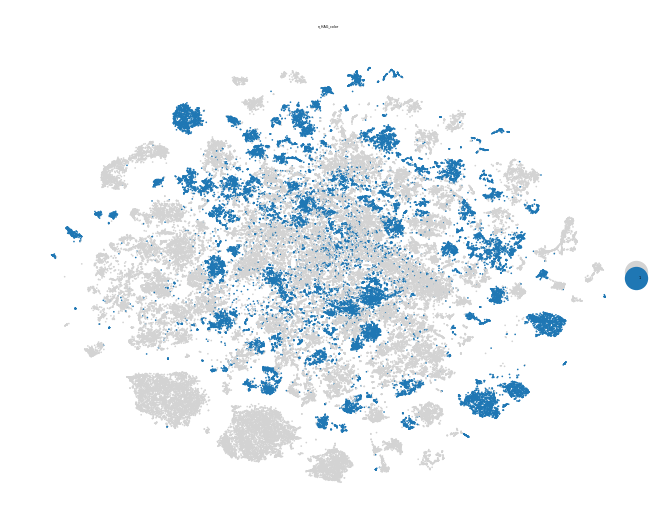

In [148]:
#removing those cells that couldn't compute the mms, because in grey they are put in a different space and like this the tsne is actually easier to read
fig, ax = plt.subplots()
nan_cells = np.array(
    [True if adata.obs.loc[x, 'Cluster_ID_res8_080822'] in no_cells_list else False for x in adata.obs_names ]
)
#ax.scatter(x=adata[nan_cells].obsm['X_umap'][:, 0], y=adata[nan_cells].obsm['X_tsne'][:, 1], color='lightgrey', s=0.2, alpha=1, label='Nan')
#plt.legend(loc='upper right', bbox_to_anchor=(1.55, 1.05))
sc.pl.tsne(adata[~nan_cells], color='n_HAG_color', palette=['lightgrey', '#1f77b4'], ax=ax, size=1)
#, save="_02122022_HAG_cutoff.png"